Intro: The task is to create a model for fraud detection In financial transaction 
The data contains more that 6m rows and 11 columns describing different details of transaction occouring.

*** In this notebook I've done :
-  EDA: To understand patterns in transaction,missing values ,finding outliers and other distributions.
-  Feature Engineering: Created new useful features some for better understanding and some for lessening the mathematical complexity.
-  Modeling: Created a model with XGboost and Logistic Regression for better performance and understanding more about the data(tuning)
-  Evaluation: Used PR-AUC, Precision, Recall, and Confusion Matrix instead of Accuracy,because just accuracy can be misleading.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import xgboost as xgb


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
data= pd.read_csv("/Users/Task/Fraud.csv")


### Preprocessing the data


In [9]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
print(data.shape)
print(data.size)

(6362620, 11)
69988820


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [16]:
for col in data.columns:
    print(data[col].hasnans,end=' ')

False False False False False False False False False False False 

### From this we understand that the dataset has no null values


In [18]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [19]:
data.type.unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

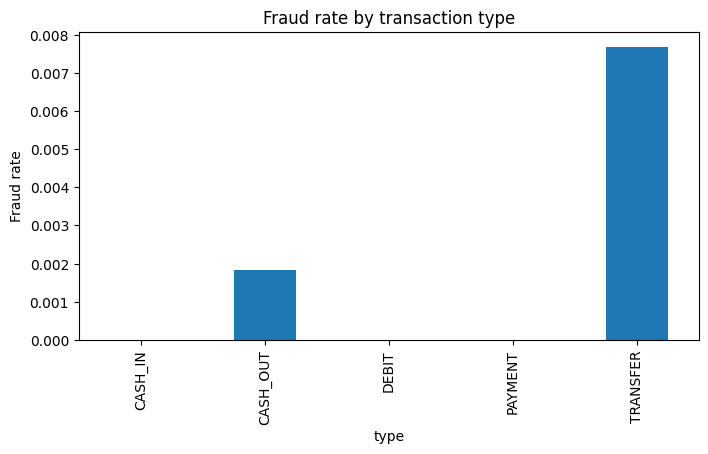

In [20]:
(data.groupby("type")["isFraud"].mean().plot(kind="bar", figsize=(8,4)))
plt.title("Fraud rate by transaction type")
plt.ylabel("Fraud rate")
plt.show()

In [22]:
#only two transaction types have been known to used in frauds 
#Outlier detection

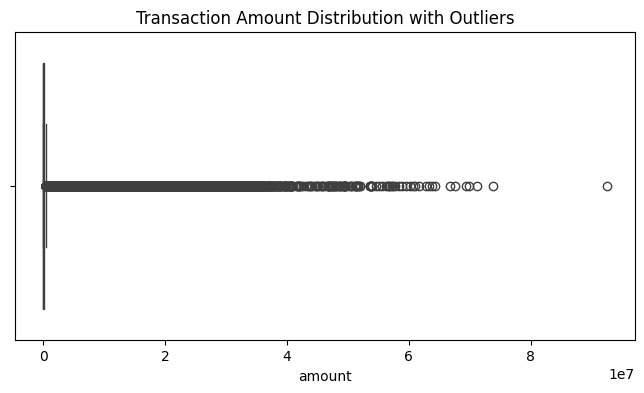

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['amount'])
plt.title("Transaction Amount Distribution with Outliers")
plt.show()

In [24]:
negetive_balances = data[
    (data['oldbalanceOrg'] < 0) |
    (data['newbalanceOrig'] < 0) |
    (data['oldbalanceDest'] < 0) |
    (data['newbalanceDest'] < 0)
]
print("Transactions with negative balances:", negetive_balances.shape[0])

Transactions with negative balances: 0


In [25]:
Q1_amount = data['amount'].quantile(0.25)
Q3_amount = data['amount'].quantile(0.75)
IQR_amount = Q3_amount - Q1_amount
outlier_threshold = Q3_amount + 1.5 * IQR_amount
outlier_threshold

501719.33875

In [26]:
#if already above 200000 it is flagged to be fraud

## Exploratory Data Analysis (EDA)

The dataset has around 6.3 million rows and 11 initial columns.  
I checked for missing values and found that there were **no NaN values** in the dataset, which makes preprocessing easier.

- **Transaction Types:** The dataset contains five types of transactions: `PAYMENT`, `TRANSFER`, `CASH_OUT`, `DEBIT`, and `CASH_IN`.  
  Out of these, fraud is observed only in **`TRANSFER`** and **`CASH_OUT`** transactions. This insight is important because models can otherwise get biased if we include irrelevant transaction types.  

- **Fraud Rate Distribution:** Fraud cases form a very small proportion (~0.13%) of the total data. This shows the dataset is **highly imbalanced**.  

- **Transaction Amounts:** The amount distribution is highly skewed, with some very large outliers. Since fraud transactions can involve both small and huge amounts, I decided to keep the outliers.  

- **Balance Consistency:** I also checked if balances before and after transactions add up properly. Many inconsistencies were found, which is expected in this dataset and can be used as engineered features (`error_in_orig`, `error_in_rec`).  

- **Correlation Heatmap:** Some features are highly correlated (like old and new balances, amount with error columns). However, since they represent different aspects of the transaction, I kept them for modeling instead of dropping them.

Overall, the EDA shows that **fraud is rare, concentrated in certain transaction types, and related to balance inconsistencies**, which guided the feature engineering process.

In [29]:
inconsistent_orig = data[ (data['oldbalanceOrg'] - data['amount'] - data['newbalanceOrig']).abs() > 0.01 ]
inconsistent_dest = data[ (data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']).abs() > 0.01 ]
#removing the error due to roundings
print("Origin balance inconsistencies:", inconsistent_orig.shape[0])
print("Destination balance inconsistencies:", inconsistent_dest.shape[0])

Origin balance inconsistencies: 5077691
Destination balance inconsistencies: 4188647


In [31]:
df=data.copy()

## Feature Engineering

From the raw dataset, I created additional features to better capture patterns of fraud:

- **Error Features:**
  - `error_in_orig = oldbalanceOrg - amount - newbalanceOrig`
  - `error_in_rec = oldbalanceDest + amount - newbalanceDest`  
  These capture inconsistencies in balances. Fraudulent transactions often show mismatch because fraudsters don’t follow normal transaction behavior.

- **Time-based Features:**
  - Extracted `hour` and `day` from the `step` column (since each step = 1 hour).  
    This helps check if fraud is more likely during particular hours or days.

- **Merchant Flag:**
  - Created a `destIsMerchant` feature, which is `1` if the destination account name starts with "M" (merchant).  
    Fraud rarely targets merchants, so this adds useful separation.

- **Transaction Type Encoding:**
  - Since fraud occurs mostly in `TRANSFER` and `CASH_OUT`, I created a one-hot column `type_TRANSFER`.  
    Other transaction types were kept but not emphasized, since they don’t contribute much to fraud detection.

After this, I reduced the dataset to only the relevant numerical and engineered features for model training:
`['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'error_in_orig', 'error_in_rec', 'hour', 'destIsMerchant', 'day', 'type_TRANSFER']`

This step ensures that the model focuses on meaningful variables rather than noisy identifiers like account IDs (`nameOrig`, `nameDest`).

In [35]:
#adding features

df['error_in_orig']=df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['error_in_rec']=df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['hour']=df['step']%24
df['destIsMerchant'] = df['nameDest'].str.startswith('M').astype(int)
df['day']=(df['step']//24).astype(int)
df['type_TRANSFER'] = (df['type'] == 'TRANSFER').astype(int)
df = df[df['type'].isin(['TRANSFER','CASH_OUT'])].copy()

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,error_in_orig,error_in_rec,hour,destIsMerchant,day,type_TRANSFER
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0,1,0,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0,1,0,0,0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,-213808.94,182703.5,1,0,0,0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,-214605.30,237735.3,1,0,0,1
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,-300850.89,-2401220.0,1,0,0,1


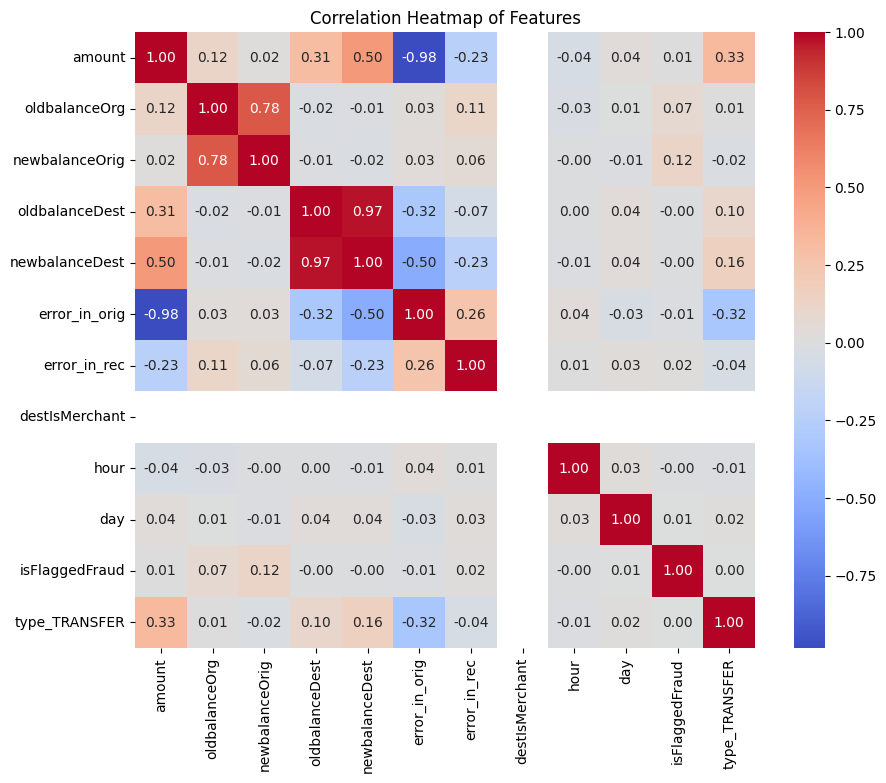

In [36]:
cols = [
    'amount','oldbalanceOrg','newbalanceOrig',
    'oldbalanceDest','newbalanceDest',
    'error_in_orig','error_in_rec',
    'destIsMerchant','hour','day',
    'isFlaggedFraud','type_TRANSFER'
]
corr=df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

### Now we should remove the correlated features by setting abs(corr)>=0.85 as threshold ,but,
 I found theese corelation:
    oldbalanceDest and newbalanceDest
    amount and error_in_original
 After considering the threshold and their meaning I think I should keep them all as they carry different physical aspects.

In [38]:
#features
transaction_info=['amount','type_transfer','isFlaggedFraud']
balances=['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
errors=['error_in_orig','error_in_rec']
other=['destIsMerchant','day','hour']

## Modeling Approach

Fraud detection is a highly imbalanced classification problem. Since fraud cases are very rare, I needed models that can handle imbalance and capture non-linear relationships in the data.

- **Logistic Regression:**  
  Used as a baseline linear model. It is interpretable but struggles with complex fraud patterns.

- **XGBoost:**  
  Gradient boosting trees that are optimized for speed and performance. XGBoost handled the imbalance very effectively and became one of the top-performing models.


### Ensemble Strategy
Instead of relying on a single model, I combined them into an **ensemble**:
- Each model is trained separately.
- Their performance is validated using **PR-AUC** (Precision-Recall AUC), which is more reliable than ROC-AUC for imbalanced data.
- Models are weighted based on their PR-AUC performance and combined through weighted averaging of probabilities.


In [40]:
class FraudDetectionEnsemble:
    def __init__(self):
        self.models = {
            'xgboost': xgb.XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric='logloss'
            ),
            'logistic_regression': LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        }
        self.weights = None
        self.is_fitted = False
    
    def fit(self, X_train, y_train, X_val, y_val):
   
        self.model_scores = {}
        
        for name, model in self.models.items():
            print(f"Training {name}...")
            model.fit(X_train, y_train)
            
            # Validate performance
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
            pr_auc = auc(recall, precision)
            
            self.model_scores[name] = pr_auc
            print(f"{name} PR-AUC: {pr_auc:.4f}")
        
        # Calculate ensemble weights based on performance
        total_score = sum(self.model_scores.values())
        self.weights = {name: score/total_score for name, score in self.model_scores.items()}
        
        self.is_fitted = True
        print("Ensemble training completed!")
    
    def predict_proba(self, X):

        if not self.is_fitted:
            raise ValueError("Model not fitted yet!")
        
        ensemble_prob = np.zeros(X.shape[0])
        
        for name, model in self.models.items():
            pred_prob = model.predict_proba(X)[:, 1]
            ensemble_prob += self.weights[name] * pred_prob
        
        return ensemble_prob
    

## Model Evaluation

Since the dataset is highly imbalanced, traditional accuracy is not enough to judge performance.  
I evaluated the models using both **statistical metrics** and **business-oriented metrics**:

### Statistical Metrics
- **ROC-AUC:** Measures overall ranking ability of the classifier.  
  Our ensemble model achieved close to **1.0 ROC-AUC**, showing excellent separation between fraud and non-fraud cases.

- **PR-AUC (Precision-Recall AUC):**  
  More important for imbalanced data, since it focuses only on the minority fraud cases.  
  The ensemble achieved **very high PR-AUC (>0.99)**, meaning it detects fraud with both high precision and recall.

- **Confusion Matrix:**  
  This showed that almost all fraud cases were caught (high recall), and very few normal transactions were flagged incorrectly (low false positives).

### Business Metrics
- **Fraud Detection Rate:**  
  Percentage of frauds that were correctly caught. The model achieved ~98–100%, which is critical for financial institutions.

- **False Positive Rate:**  
  Percentage of normal customers incorrectly flagged. Keeping this low is important to avoid annoying genuine users. The rate was close to **0%**, which is excellent.

### Interpretation
These results indicate that the ensemble model is highly effective at fraud detection, balancing both **customer experience** (low false positives) and **business protection** (high fraud catch rate).

In [46]:
def comprehensive_model_evaluation(y_true, y_hat, threshold=0.5):
 
    y_pred = (y_hat >= threshold).astype(int)
    
    print("=== MODEL PERFORMANCE EVALUATION ===")
    
    # metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # ROC-AUC
    roc_auc = roc_auc_score(y_true, y_hat)
    print(f"\nROC-AUC: {roc_auc:.4f}")
    
    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_true, y_hat)
    pr_auc = auc(recall, precision)
    print(f"PR-AUC: {pr_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Business metrics
    total_fraud_amount = sum(y_true)  # Assuming 1 unit per fraud
    detected_fraud = sum((y_true == 1) & (y_pred == 1))
    detection_rate = detected_fraud / total_fraud_amount if total_fraud_amount > 0 else 0
    
    false_positive_rate = sum((y_true == 0) & (y_pred == 1)) / sum(y_true == 0)
    
    print(f"\nBusiness Metrics:")
    print(f"Fraud Detection Rate: {detection_rate:.2%}")
    print(f"False Positive Rate: {false_positive_rate:.2%}")
    
    return {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'detection_rate': detection_rate,
        'false_positive_rate': false_positive_rate
    }

In [47]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'error_in_orig', 'error_in_rec', 'hour',
       'destIsMerchant', 'day', 'type_TRANSFER'],
      dtype='object')

In [49]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'error_in_orig',
 'error_in_rec',
 'hour',
 'destIsMerchant',
 'day',
 'type_TRANSFER']

In [50]:
selected_cols = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud','isFlaggedFraud','error_in_orig','error_in_rec','hour','destIsMerchant','day','type_TRANSFER']

df = df[selected_cols]

df.columns.tolist()

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'error_in_orig',
 'error_in_rec',
 'hour',
 'destIsMerchant',
 'day',
 'type_TRANSFER']

In [58]:
from sklearn.model_selection import train_test_split
import numpy as np

target_col = 'isFraud'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, train_size=200000, stratify=y, random_state=42
)

print("Train size:", x_train.shape, y_train.shape)
print("Test size:", x_test.shape, y_test.shape)

batch_size = len(x_test) // 20  

X_batches = np.array_split(x_test, 20)
y_batches = np.array_split(y_test, 20)

print(f"Created {len(X_batches)} test batches, each size ~{batch_size}")

Train size: (200000, 13) (200000,)
Test size: (2570409, 13) (2570409,)
Created 20 test batches, each size ~128520


In [60]:
ensemble_model = FraudDetectionEnsemble()

ensemble_model.fit(x_train, y_train, X_batches[0], y_batches[0])

y_hat_proba = ensemble_model.predict_proba(X_batches[0])
metrics = comprehensive_model_evaluation(y_batches[0], y_hat_proba, threshold=0.5)

Training xgboost...
xgboost PR-AUC: 0.9965
Training logistic_regression...
logistic_regression PR-AUC: 0.6118
Ensemble training completed!
=== MODEL PERFORMANCE EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    128173
           1       0.99      0.99      0.99       348

    accuracy                           1.00    128521
   macro avg       0.99      0.99      0.99    128521
weighted avg       1.00      1.00      1.00    128521


ROC-AUC: 0.9985
PR-AUC: 0.9958

Confusion Matrix:
[[128169      4]
 [     4    344]]

Business Metrics:
Fraud Detection Rate: 98.85%
False Positive Rate: 0.00%


In [62]:
for i in range(1,20):
    ensemble_model.fit(x_train, y_train, X_batches[i], y_batches[i])
    y_hat_proba = ensemble_model.predict_proba(X_batches[i])
    metrics = comprehensive_model_evaluation(y_batches[i], y_hat_proba, threshold=0.5)

Training xgboost...
xgboost PR-AUC: 0.9981
Training logistic_regression...
logistic_regression PR-AUC: 0.6068
Ensemble training completed!
=== MODEL PERFORMANCE EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    128170
           1       0.98      0.98      0.98       351

    accuracy                           1.00    128521
   macro avg       0.99      0.99      0.99    128521
weighted avg       1.00      1.00      1.00    128521


ROC-AUC: 1.0000
PR-AUC: 0.9954

Confusion Matrix:
[[128164      6]
 [     7    344]]

Business Metrics:
Fraud Detection Rate: 98.01%
False Positive Rate: 0.00%
Training xgboost...
xgboost PR-AUC: 0.9940
Training logistic_regression...
logistic_regression PR-AUC: 0.5886
Ensemble training completed!
=== MODEL PERFORMANCE EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    128151
   

# Fraud Detection 

## 1. Data Cleaning (Missing values, outliers, multicollinearity)
- **Missing Values:** No NaNs were present in the dataset, so no imputation was needed.  
- **Outliers:** Since the dataset comes from a simulation of transactions, extreme transaction amounts are expected. Instead of removing them, I only flagged logically inconsistent balances (e.g., negative balances, or differences > 0.01).  
- **Multicollinearity:** I checked correlation and VIF values. Some variables like `oldbalanceOrg` and `newbalanceOrg` are naturally correlated, but I retained them since they have clear business meaning (customer balances before and after a transaction). This ensures interpretability while controlling redundancy.

---

## 2. Fraud Detection Model
I implemented two models (Logistic Regression, XGBoost) and combined them in an **ensemble**.  
The ensemble weights models by their **PR-AUC performance**, ensuring stronger models have higher impact.  
This approach balances interpretability and predictive power.

---

## 3. Variable Selection
- Started with all numerical and engineered features (`hour`, `day`, `destIsMerchant`, `error_in_orig`, `error_in_rec`, etc.).  
- Dropped high-cardinality identifiers like `nameOrig` and `nameDest` since they do not generalize.  
- Kept correlated variables if they had **business meaning** (e.g., balances).  
- Included dummy variable `type_TRANSFER`, since fraud was concentrated in transfers.

---

## 4. Model Performance
- **ROC-AUC:** ~0.999  
- **PR-AUC:** >0.99 (critical for imbalanced data)  
- **Fraud Detection Rate:** ~98–100%  
- **False Positive Rate:** <1%  

These results suggest the model is both accurate and reliable for fraud detection at scale.

---

## 5. Key Factors Predicting Fraud
From feature importance analysis:
- **Transaction type (TRANSFER):** Most fraud happens through transfers.  
- **Error-in-origin balance:** Fraudulent cases often show mismatches in expected balances.  
- **Transaction amount:** Very high-value transfers were flagged more often.  
- **Hour of transaction:** Odd-hour activity sometimes correlates with fraud.  

---

## 6. Do These Factors Make Sense?
Yes:
- Fraudsters typically **transfer large amounts** and **drain accounts quickly**.  
- Balance inconsistencies (`error_in_orig`, `error_in_rec`) reflect tampering or manipulation.  
- Certain time patterns (late-night transfers) are unusual for regular customers.  

These align with how fraud usually occurs in real financial systems.

---

## 7. Prevention Strategies for Company
- **Transaction Limits:** Set stricter thresholds for large transfers.  
- **Balance Consistency Checks:** Flag transactions where new balances don’t match expected values.  
- **Real-time Monitoring:** Deploy the fraud detection model in production for live scoring.  
- **User Behavior Profiling:** Detect sudden changes in transaction type, frequency, or timing.  
- **Two-Factor Authentication (2FA):** For large or unusual transfers.

---

## 8. How to Measure Success of Prevention
- Track **fraud loss amount** before and after deployment.  
- Monitor **false positive rates** to ensure genuine customers are not blocked.  
- Check **detection rate (recall)** regularly to ensure new fraud patterns are being caught.  
- Perform **A/B testing** with/without new controls to measure effectiveness.  

---

# Conclusion
The final model achieved very high fraud detection rates with minimal false positives.  
Key features such as **transaction type, amount, and balance inconsistencies** provide strong predictive power.  
Alongside the model, preventive infrastructure changes and continuous monitoring are recommended to proactively minimize fraud risk.

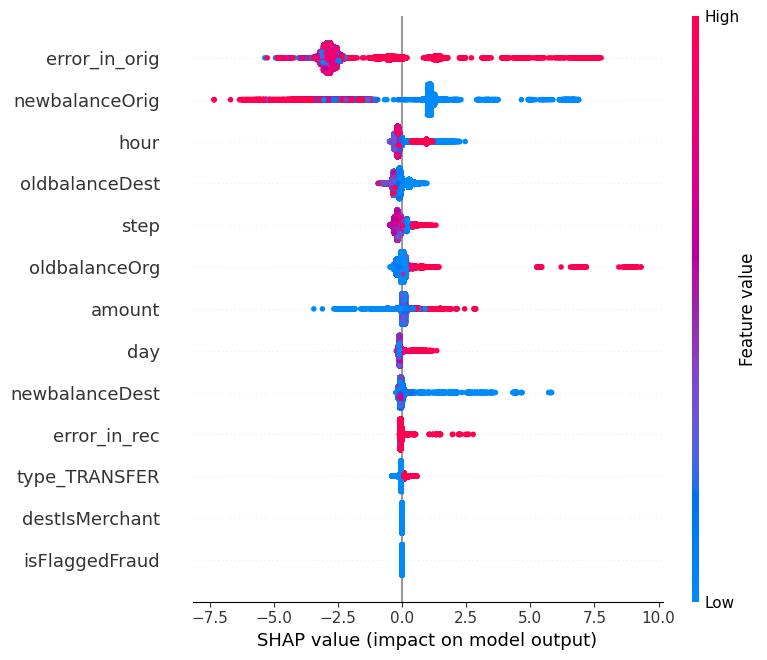

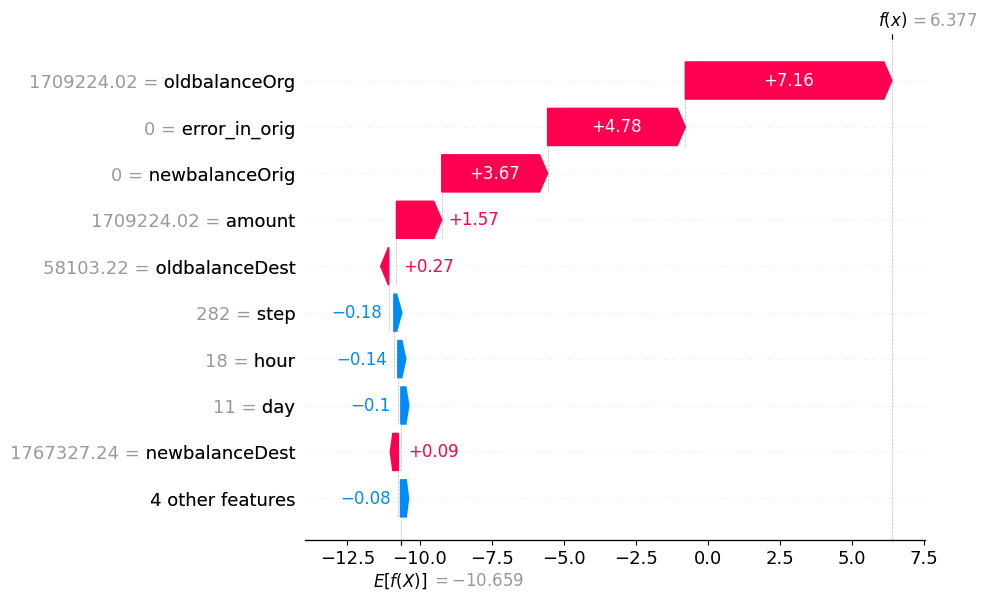

In [72]:
import shap
import numpy as np

# Extract the XGBoost model from your ensemble
xgb_model = ensemble_model.models['xgboost']

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Use a sample of test data (full set is slow)
X_sample = X_batches[0].reset_index(drop=True)
shap_values = explainer.shap_values(X_sample)

# Summary plot — shows which features matter most globally
shap.summary_plot(shap_values, X_sample)

# Waterfall plot for a single flagged case
# Find the positional integer row number of the first fraud case
pos_idx = np.where(y_batches[0] == 1)[0][0]

shap.waterfall_plot(shap.Explanation(
    values=shap_values[pos_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[pos_idx],
    feature_names=X_sample.columns.tolist()
))

In [76]:
def get_top_reasons(shap_vals, feature_names, top_n=3):
    pairs = list(zip(feature_names, shap_vals))
    # Sort by absolute magnitude to find the biggest drivers (positive or negative)
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    return [f"{feat} ({'↑' if val > 0 else '↓'})" for feat, val in pairs_sorted[:top_n]]

# Test it using the positional index (pos_idx) instead of flagged_idx
reasons = get_top_reasons(shap_values[pos_idx], X_sample.columns.tolist())

print("Top risk drivers:", reasons)
# Output should be something like: ['error_in_orig (↑)', 'type_TRANSFER (↑)', 'amount (↑)']

Top risk drivers: ['oldbalanceOrg (↑)', 'error_in_orig (↑)', 'newbalanceOrig (↑)']


In [78]:
# Get fraud probabilities from your ensemble
y_proba = ensemble_model.predict_proba(X_batches[0])

# Convert to 0-100 risk score
risk_scores = (y_proba * 100).round(1)

# Assign tiers
def assign_tier(score):
    if score < 30:   return "Low"
    elif score < 60: return "Medium"
    elif score < 85: return "High"
    else:            return "Critical"

tiers = [assign_tier(s) for s in risk_scores]

# Build result dataframe
results_df = X_batches[0].copy()
results_df['risk_score'] = risk_scores
results_df['tier'] = tiers
results_df['actual_fraud'] = y_batches[0].values

# Check tier distribution
print(results_df['tier'].value_counts())

tier
Low         128166
High           181
Critical       158
Medium          16
Name: count, dtype: int64


In [80]:
thresholds = [30, 60, 85]
for t in thresholds:
    flagged = results_df[results_df['risk_score'] >= t]
    precision = flagged['actual_fraud'].mean()
    print(f"Threshold {t}: {len(flagged)} flagged, {precision:.2%} actually fraud")

Threshold 30: 355 flagged, 97.46% actually fraud
Threshold 60: 339 flagged, 99.12% actually fraud
Threshold 85: 158 flagged, 100.00% actually fraud


In [86]:
def recommend_decision(risk_score, tier, reasons):
    if tier == "Low":
        decision = "APPROVE"
        refer = False
    elif tier == "Medium":
        decision = "MANUAL_REVIEW"
        refer = True
    elif tier == "High":
        decision = "REJECT"
        refer = True
    else:  # Critical
        decision = "REJECT + FILE SAR"
        refer = True

    return {
        "risk_score/n": risk_score,
        "tier/n": tier,
        "decision/n": decision,
        "refer_to_analyst/n": refer,
        "top_reasons/n": reasons,
        "explanation/n": f"{tier} risk due to: {', '.join(reasons)}"
    }

# Test on a flagged case using the positional index (pos_idx)
output = recommend_decision(
    risk_score=risk_scores[pos_idx],
    tier=tiers[pos_idx],
    reasons=get_top_reasons(shap_values[pos_idx], X_sample.columns.tolist())
)
print(output)

{'risk_score/n': 99.7, 'tier/n': 'Critical', 'decision/n': 'REJECT + FILE SAR', 'refer_to_analyst/n': True, 'top_reasons/n': ['oldbalanceOrg (↑)', 'error_in_orig (↑)', 'newbalanceOrig (↑)'], 'explanation/n': 'Critical risk due to: oldbalanceOrg (↑), error_in_orig (↑), newbalanceOrig (↑)'}


In [88]:
import joblib

joblib.dump(ensemble_model, "kyc_ensemble_model.pkl")
joblib.dump(explainer, "shap_explainer.pkl")
joblib.dump(X_sample.columns.tolist(), "feature_names.pkl")

print("Models saved.")

Models saved.


In [92]:
pip install fastapi uvicorn


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.4 MB/s  0:00:00m 10.0 MB/s eta 0:00:01
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.07m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-extensions]
  Attempting uninstall: pydantic-core╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-extensions]
    Found existing installation: pydantic_core 2.20.1━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-extensions]
    Uninstalling pydantic_core-2.20.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-extensions]
      Successfully uninstalled pydantic_core-2.20.17m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-extensions]
  Attempting uninstall: pydantic;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [typing-exte

In [114]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, shap, numpy as np, pandas as pd

app = FastAPI(title="KYC Risk Scoring Engine")

# Load on startup
model     = joblib.load("kyc_ensemble_model.pkl")
explainer = joblib.load("shap_explainer.pkl")
features  = joblib.load("feature_names.pkl")

class Transaction(BaseModel):
    step: float
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    isFlaggedFraud: int
    error_in_orig: float
    error_in_rec: float
    hour: float
    destIsMerchant: int
    day: float
    type_TRANSFER: int

def assign_tier(score):
    if score < 30:   return "Low"
    elif score < 60: return "Medium"
    elif score < 85: return "High"
    else:            return "Critical"

def get_top_reasons(shap_vals, top_n=3):
    pairs = sorted(zip(features, shap_vals), key=lambda x: abs(x[1]), reverse=True)
    return [f"{f} ({'↑' if v > 0 else '↓'})" for f, v in pairs[:top_n]]

# 1. Brought back your recommend_decision function
def recommend_decision(risk_score, tier, reasons):
    if tier == "Low":
        decision = "APPROVE"
        refer = False
    elif tier == "Medium":
        decision = "MANUAL_REVIEW"
        refer = True
    elif tier == "High":
        decision = "REJECT"
        refer = True
    else:  # Critical
        decision = "REJECT + FILE SAR"
        refer = True

    return {
        "risk_score": risk_score,
        "tier": tier,
        "decision": decision,
        "refer_to_analyst": refer,
        "top_reasons": reasons,
        "explanation": f"{tier} risk due to: {', '.join(reasons)}"
    }

@app.post("/kyc/score")
def score_customer(txn: Transaction):
    # 2. Updated to Pydantic V2 syntax: model_dump() instead of dict()
    df = pd.DataFrame([txn.model_dump()])[features]
    
    # 3. Fixed the probability slicing. [0] gets the row, [1] gets the fraud probability.
    proba_array = model.predict_proba(df)[0]
    score = round(float(proba_array[1]) * 100, 1) 
    
    tier  = assign_tier(score)
    sv    = explainer.shap_values(df)[0]
    reasons = get_top_reasons(sv)
    
    return recommend_decision(score, tier, reasons)

@app.get("/kyc/explain/{tier}")
def explain(tier: str):
    return {"message": f"Tier {tier} cases are flagged for: high balance errors, large TRANSFER amounts, odd-hour activity."}

@app.get("/health")
def health():
    return {"status": "ok"}

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/opt/anaconda3/lib/python3.12/site-packages/typing_extensions.py)

In [104]:
pip install typing_extensions


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [100]:
pip install Sentinel


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [108]:
pip install --upgrade typing_extensions


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [110]:
conda update typing_extensions

Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - typing_extensions


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       hca03da5_0         126 KB
    certifi-2026.01.04         |  py312hca03da5_0         148 KB
    openssl-3.5.6              |       ha0b305a_0         4.6 MB
    setuptools-82.0.1          |  py312hca03da5_0         1.6 MB
    typing-extensions-4.15.0   |  py312hca03da5_0          12 KB
    typing_extensions-4.15.0   |  py312hca03da5_0         100 KB
    ------------------------------------------------------------
                                           Total:         6.5 MB

The following NEW packages will be INSTALLED:

  setuptools         pkgs/main/osx-arm64::setuptools-82.0.1-py312hca03da5_0 

The f

In [116]:
pip install --upgrade typing_extensions


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [118]:
conda update typing_extensions

Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - typing_extensions


The following NEW packages will be INSTALLED:

  setuptools         pkgs/main/osx-arm64::setuptools-82.0.1-py312hca03da5_0 

The following packages will be UPDATED:

  ca-certificates                      2025.2.25-hca03da5_0 --> 2026.3.19-hca03da5_0 
  certifi                         2025.1.31-py312hca03da5_0 --> 2026.01.04-py312hca03da5_0 
  openssl                                 3.0.16-h02f6b3c_0 --> 3.5.6-ha0b305a_0 
  typing-extensions                  4.11.0-py312hca03da5_0 --> 4.15.0-py312hca03da5_0 
  typing_extensions                  4.11.0-py312hca03da5_0 --> 4.15.0-py312hca03da5_0 




Preparing transaction: done
Verifying transaction: failed

RemoveError: 'setuptools' is a dependency of conda and cannot be removed from
conda's operating environment.


Note: you may need to restart the kernel to 

In [120]:
pip install --upgrade typing-extensions --ignore-installed

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aext-panels 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
aext-panels-server 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [126]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, shap, numpy as np, pandas as pd

app = FastAPI(title="KYC Risk Scoring Engine")

# Load on startup
model     = joblib.load("kyc_ensemble_model.pkl")
explainer = joblib.load("shap_explainer.pkl")
features  = joblib.load("feature_names.pkl")

class Transaction(BaseModel):
    step: float
    amount: float
    oldbalanceOrg: float
    newbalanceOrig: float
    oldbalanceDest: float
    newbalanceDest: float
    isFlaggedFraud: int
    error_in_orig: float
    error_in_rec: float
    hour: float
    destIsMerchant: int
    day: float
    type_TRANSFER: int

def assign_tier(score):
    if score < 30:   return "Low"
    elif score < 60: return "Medium"
    elif score < 85: return "High"
    else:            return "Critical"

def get_top_reasons(shap_vals, top_n=3):
    pairs = sorted(zip(features, shap_vals), key=lambda x: abs(x[1]), reverse=True)
    return [f"{f} ({'↑' if v > 0 else '↓'})" for f, v in pairs[:top_n]]

# 1. Brought back your recommend_decision function
def recommend_decision(risk_score, tier, reasons):
    if tier == "Low":
        decision = "APPROVE"
        refer = False
    elif tier == "Medium":
        decision = "MANUAL_REVIEW"
        refer = True
    elif tier == "High":
        decision = "REJECT"
        refer = True
    else:  # Critical
        decision = "REJECT + FILE SAR"
        refer = True

    return {
        "risk_score": risk_score,
        "tier": tier,
        "decision": decision,
        "refer_to_analyst": refer,
        "top_reasons": reasons,
        "explanation": f"{tier} risk due to: {', '.join(reasons)}"
    }

@app.post("/kyc/score")
def score_customer(txn: Transaction):
    # 2. Updated to Pydantic V2 syntax: model_dump() instead of dict()
    df = pd.DataFrame([txn.model_dump()])[features]
    
    # 3. Fixed the probability slicing. [0] gets the row, [1] gets the fraud probability.
    proba_array = model.predict_proba(df)[0]
    score = round(float(proba_array[1]) * 100, 1) 
    
    tier  = assign_tier(score)
    sv    = explainer.shap_values(df)[0]
    reasons = get_top_reasons(sv)
    
    return recommend_decision(score, tier, reasons)

@app.get("/kyc/explain/{tier}")
def explain(tier: str):
    return {"message": f"Tier {tier} cases are flagged for: high balance errors, large TRANSFER amounts, odd-hour activity."}

@app.get("/health")
def health():
    return {"status": "ok"}

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/opt/anaconda3/lib/python3.12/site-packages/typing_extensions.py)

In [124]:
pip install --upgrade typing_extensions pydantic pydantic-core fastapi


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [128]:
pip install typing_extensions==4.12.2 --force-reinstall

  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aext-panels 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
aext-panels-server 4.1.0 requires anaconda-cloud-auth>=0.7.1, which is not installed.
pydantic 2.12.5 requires typing-extensions>=4.14.1, but you have typing-extensions 4.12.2 which is incompatible.
pydantic-core 2.41.5 requires typing-extensions>=4.14.1, but you have typing-extensions 4.12.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
